Examples.
- Drawing lattices and paths
- Floating point dimer-dimer correlator and vison correlator
- Fraction-free examples and sparse integer determinant

In [1]:
from functions.kasteleyn_shapes import *
from functions.kasteleyn_inverse import *
from functions.kasteleyn_fflu import *
setfont() # set font to Times

0

## Drawing lattices and paths

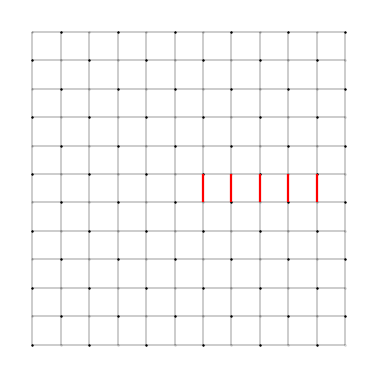

0

In [2]:
mpl.rcParams['figure.dpi'] = 40
plot_shape(12,square_coord, axes=False, string=get_default_string(12, square_coord))

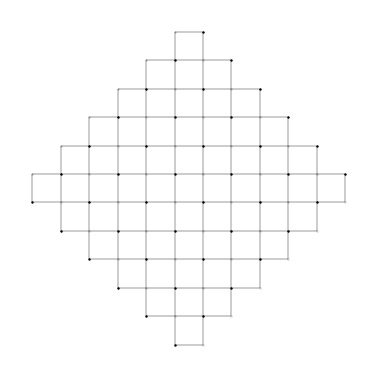

0

In [3]:
mpl.rcParams['figure.dpi'] = 40
plot_shape(12,aztec_coord, axes=False)

The square-octagon lattice can be drawn in a square lattice.
Vertex coordinates (row, col) for the square-octagon lattice are inherited from the square lattice.
Octagon faces in the square-octagon lattice are represented by size 1x3 rectangles.

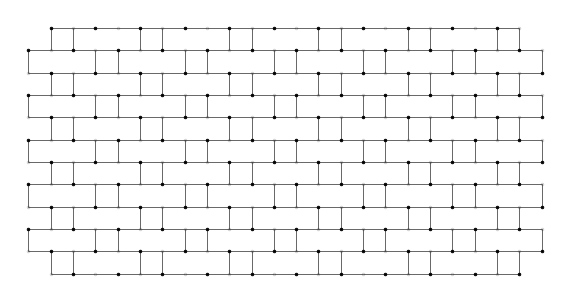

0

In [4]:
mpl.rcParams['figure.dpi'] = 60
plot_shape(12,octagon_square_coord, axes=False)

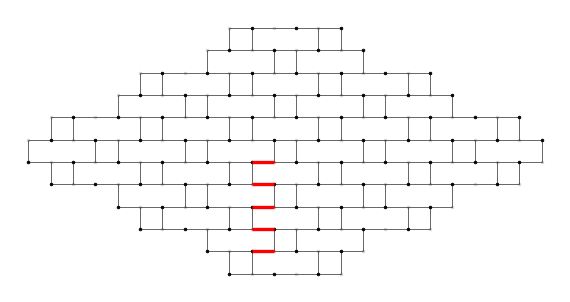

0

In [5]:
mpl.rcParams['figure.dpi'] = 60
plot_shape(12,octagon_fortress_coord, axes=False, string=get_default_string(12, octagon_fortress_coord))

The square-octagon lattices can also be drawn with actual octagon faces.
However, all other code uses the lattice coordinates inherited from a square lattice.

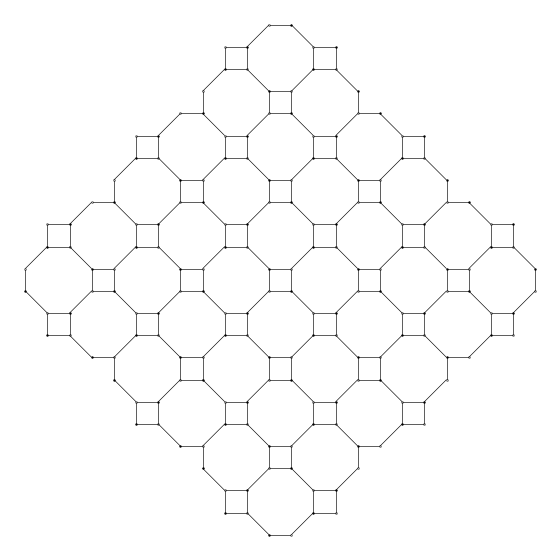

In [6]:
mpl.rcParams['figure.dpi'] = 30
plot_shape_octagons(12, octagon_fortress_coord);

Here is a similar lattice which is NOT the same as the square-octagon fortress.

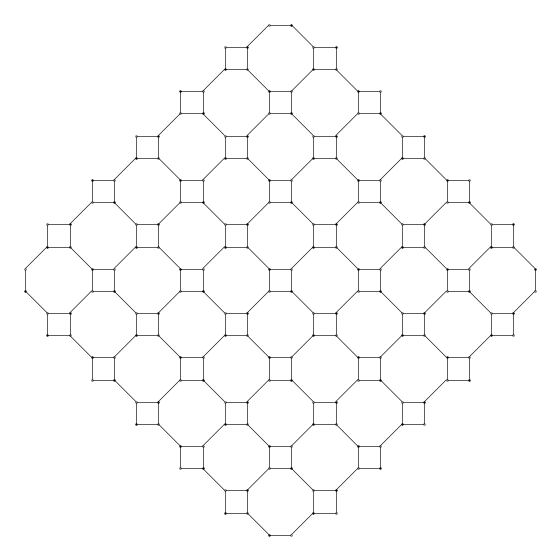

In [7]:
mpl.rcParams['figure.dpi'] = 30
plot_shape_octagons(12, octagon_fakefortress_coord);

## Floating point dimer-dimer correlator and vison correlator

When the condition number of the Kasteleyn matrix is small and we do not need high precision, 
we can using standard floating point calculations instead of fraction-free methods.
These are much faster and more convenient, but they can be unreliable due to numerical error when the condition
number is large, as it is for the Aztec diamond and square-octagon fortress shapes.
For rectangular boundary conditions however these methods can be very convenient.

Computed sparse LU factorization in 0.50 seconds


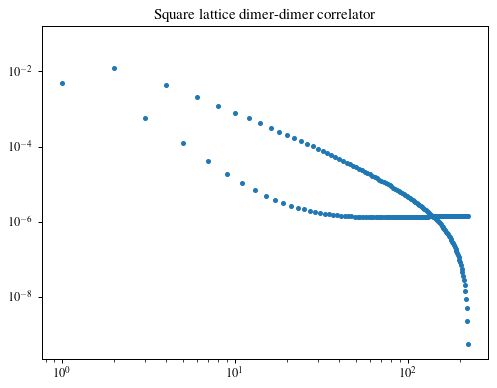

In [8]:
mpl.rcParams['figure.dpi'] = 90
d_square = dimer_fast(450, square_coord, get_default_string(450, square_coord))
plt.plot(np.abs(d_square), '.')
plt.title('Square lattice dimer-dimer correlator')
plt.yscale('log')
plt.xscale('log')
plt.show()

Computed sparse LU factorization in 0.48 seconds


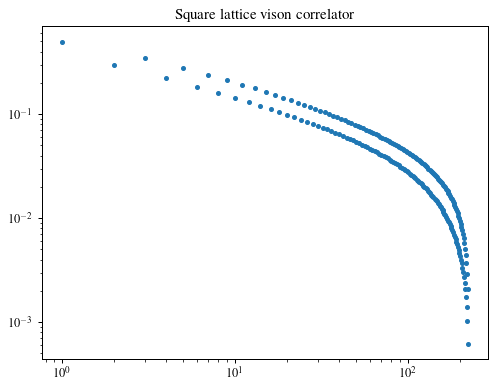

In [9]:
mpl.rcParams['figure.dpi'] = 90
v_square = vison_fast(450, square_coord, get_default_string(450, square_coord))
plt.plot(np.abs(v_square), '.')
plt.title('Square lattice vison correlator')
plt.yscale('log')
plt.xscale('log')
plt.show()

Computed sparse LU factorization in 0.00 seconds


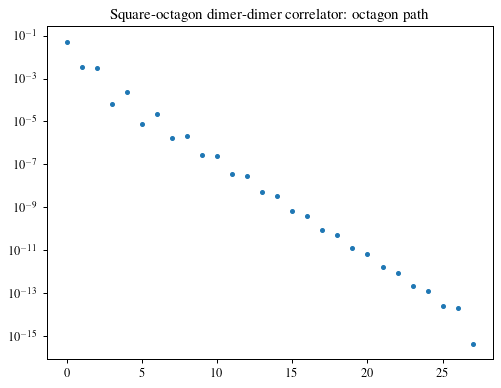

In [10]:
mpl.rcParams['figure.dpi'] = 90
d_sqoct = dimer_fast(60, octagon_square_coord, get_default_string(60, octagon_square_coord))
plt.plot(np.abs(d_sqoct), '.')
plt.title('Square-octagon dimer-dimer correlator: octagon path')
plt.yscale('log')
plt.show()

Computed sparse LU factorization in 0.59 seconds


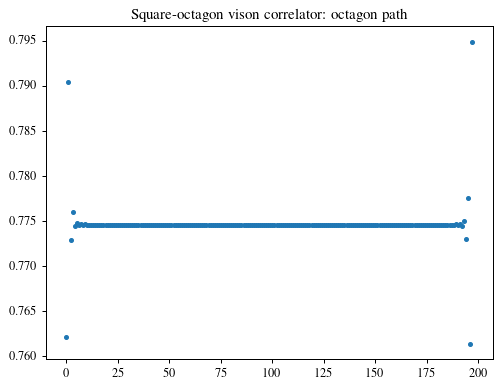

In [11]:
mpl.rcParams['figure.dpi'] = 90
v_sqoct_oct = vison_fast(400, octagon_square_coord, get_default_string(400, octagon_square_coord))
plt.plot(np.abs(v_sqoct_oct), '.')
plt.title('Square-octagon vison correlator: octagon path')
plt.show()

### Issues

As seen in the plots below, the floating point accuracy can break down around the precision limit 10^(-16), even with good matrix condition number. However, if we do not need precision beyond 10^(-16), these methods are still ok (provided the condition number is not too large).

Computed sparse LU factorization in 0.09 seconds


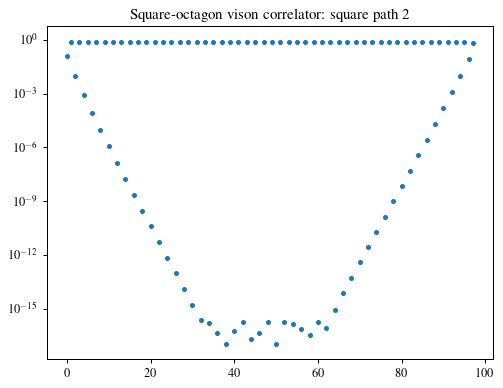

In [12]:
mpl.rcParams['figure.dpi'] = 90
v_sqoct_oct = vison_fast(200, octagon_square_coord, get_default_string(200, octagon_square_coord, squares=True))
plt.plot(np.abs(v_sqoct_oct), '.')
plt.title('Square-octagon vison correlator: square path 2')
plt.yscale('log')
plt.show()

Computed sparse LU factorization in 0.09 seconds


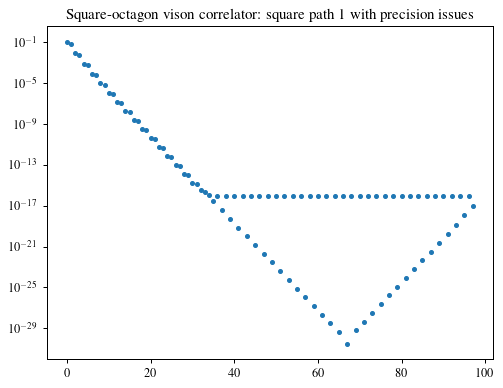

In [13]:
mpl.rcParams['figure.dpi'] = 90
v_sqoct_oct = vison_fast(200, octagon_square_coord, get_default_string(200, octagon_square_coord, \
                                                                       squares=True,squarestart=0))
plt.plot(np.abs(v_sqoct_oct), '.')
plt.title('Square-octagon vison correlator: square path 1 with precision issues')
plt.yscale('log')
plt.show()

### Condition number issues

The Kasteleyn matrix for the Aztec diamond or square-octagon fortress has a large condition number,
meaning that LU decomposition can be unreliable. As seen below, attempting to use the standard
floating-point methods can produce a vison correlator >1, which is impossible. Using the floating point inverse to calculate edge probabilities can also produce visibly incorrect results.

Computed sparse LU factorization in 0.03 seconds


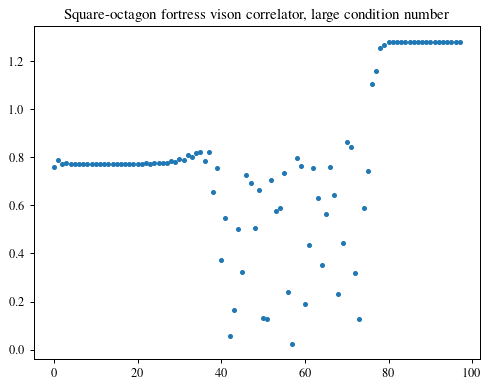

In [14]:
mpl.rcParams['figure.dpi'] = 90
v_sqoct_oct_fortress = vison_fast(200, octagon_fortress_coord, get_default_string(200, octagon_fortress_coord))
plt.plot(np.abs(v_sqoct_oct_fortress), '.')
plt.title('Square-octagon fortress vison correlator, large condition number')
plt.show()

## Fraction-free examples

To avoid the floating point issues above, we implement the fraction-free sparse LU (FFLU) algorithms from
1. Lee and Saunders, Fraction Free Gaussian Elimination for Sparse Matrices, J. Symb. Comput. 19, 393 (1995).
2. Nakos, Turner, and Williams, Fraction-free Gaussian algorithms for linear and polynomial equations, ACM SIGSAM Bull. 31, 11 (1997).

This allows for exact calculation of the Kasteleyn matrix inverse K^{-1} and thus of the correlators. In practice, we use the mpmath module to calculate all necessary matrix elements of K^{-1} and all correlators using ~200 decimal places.

For simplicity, we only give some small examples below using single-threaded functions. For larger system sizes, including those used in the paper, see some multithreaded versions in kasteleyn_fflu.py. The multithreaded FFLU functions generally save their integer outputs to .npy files (since for large systems the calculations can take a long time). The values can then be loaded and used with the mpmath module to calculate the correlators to arbitrary precision. 

Pivoting is NOT implemented, since it was not needed for the Kasteleyn matrices. For general matrices, if a pivot is 0, it will return an error.

In [15]:
lu = lu_sparse(kasteleyn_shape(72,octagon_fortress_coord))

matrix size N=2700
Calculated sparse B matrix in 1.28 seconds
Calculated LU matrix A from B in 2.82 seconds


The LU matrix can be saved as a .npy file. Loading the saved LU matrix file requires allow_pickle=True, followed by converting to a python list, e.g. 
np.save('filename', lu)
lu2 = np.load('filename', allow_pickle=True).tolist()

Once we have the LU decomposition, we perform the forward and back-substitution to solve for the required elements of K^{-1}. The integer results can be saved to .npy files (by creating the appropriate folder and setting the option save=True), to be loaded later. This part can be easily multithreaded.

The small K^{-1} calculated below is along the 'octagon path' in the square-octagon fortress, and uses mpmath division with mp.mp.dps=200.

In [16]:
n=72
kinvsmall = kinv_ff(n, kasteleyn_shape(n,octagon_fortress_coord), octagon_fortress_coord, \
            string=get_default_string(n, octagon_fortress_coord), lu=lu, save=False, divdps=200)
ksmall = shrinkone(n, octagon_fortress_coord, kasteleyn_shape(n, octagon_fortress_coord),\
                  string=get_default_string(n, octagon_fortress_coord)).toarray()

Computed kinvsmall from LU decomp. in 23.14 seconds


Dimer-dimer and vison correlators are then calculated from the small K and K^{-1} using the mpmath module.

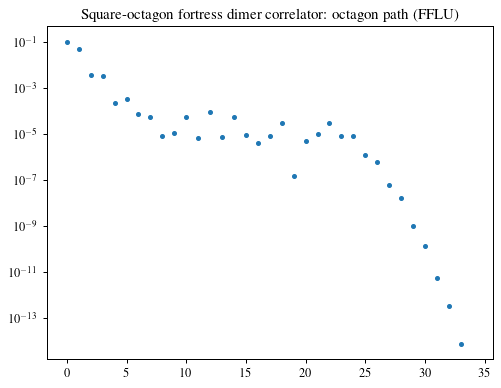

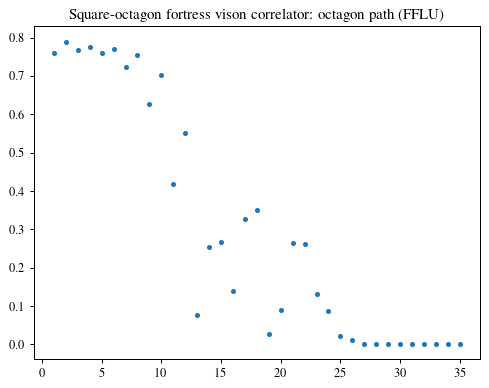

In [17]:
setfont()
mpl.rcParams['figure.dpi'] = 90
mp.mp.dps=200

d_fortress = mp_dimer_fast_fromsmall(ksmall, kinvsmall, length=35)
plt.plot(np.abs(d_fortress), '.')
plt.title('Square-octagon fortress dimer correlator: octagon path (FFLU)')
plt.yscale('log')
plt.show()

v_fortress = mp_vison_fast_fromsmall(ksmall, kinvsmall, length=35, verbose=False)
plt.plot(range(1,36), np.abs(v_fortress), '.')
plt.title('Square-octagon fortress vison correlator: octagon path (FFLU)')
plt.show()

### Multithreading



In [18]:
# Returns small K^{-1} submatrix and also saves fraction-free (integer) values to folder 
# 'sqoct_fortress_n%i_fflu/'%n'
n=72
kinvsmall_mup = kinv_ff_mup(n, kasteleyn_shape(n,octagon_fortress_coord), octagon_fortress_coord, \
                            string=get_default_string(n, octagon_fortress_coord))

Created folder sqoct_fortress_n72_fflu/
matrix size N=2700
Calculated sparse B matrix in 1.27 seconds
Calculated LU matrix A from B in 2.79 seconds
Computed sparse LU decomposition in 4.23 seconds
using 8 threads to calculate kinvsmall from LU
Computed kinvsmall from LU decomp. in 4.60 seconds


In [19]:
# Running kinv_ff_mup saves integer solutions as .npy files, which we can use to re-calculate the small K^{-1}
# submatrix quickly
n=72
kinvsmall_load = mp_kinv_from_lusol(n,octagon_fortress_coord,get_default_string(n,octagon_fortress_coord),\
                                   'sqoct_fortress_n%i_fflu/'%n, dps=300)

In [20]:
# check K^{-1} is the same
mp.mp.dps=300
print(mp.norm(mp.matrix(kinvsmall_mup) - kinvsmall_load, p='inf'))

3.93573520744533150097760386501882665029704264977513657566134009429689613324380615635901041768382630525315843975134748878448085495992646048532584063355337675183842738389365291868557049581293972085535527277727614138959468283654298358353676017998922385334395256719202303468936464308012912488929855047615e-202


In [21]:
# requires kinvsmall computed from the single thread section
mp.mp.dps=300
print(mp.norm(mp.matrix(kinvsmall) - kinvsmall_load, p='inf'))

3.93573520744533150097760386501882665029704264977513657566134009429689613324380615635901041768382630525315843975134748878448085495992646048532584063355337675183842738389365291868557049581293972085535527277727614138959468283654298358353676017998922385334395256719202303468936464308012912488929855047615e-202


### Fraction-free sparse determinant

Using the algorithm from
1. Lee and Saunders, Fraction Free Gaussian Elimination for Sparse Matrices, J. Symb. Comput. 19, 393 (1995).

Row swapping to handle zero pivots is implemented.

In [22]:
%time ks50 = det_sparse(kasteleyn_shape(50,square_coord))
print(ks50)

matrix size N=1250
CPU times: user 2.15 s, sys: 6.97 ms, total: 2.16 s
Wall time: 2.16 s
-13387002183802072716437005804888384441697410003874375430286852581949300261913933145386680332191206245205836916128245329463697459788523703869716797516723198428105735536547489363891924530854843281971402707682104980441345554496849387939828560297900082136731589456819325959305128048082453866925961423503570646335488


In [23]:
# check that this agrees with Kasteleyn's formula for the number of dimer coverings on the square lattice
# \prod_{j=1}^{n/2}\prod_{k=1}^n \sqrt{4 cos^2(\pi j/(n+1)) + 4 cos^2(\pi k/(n+1))}
n=50
mp.mp.dps = 400
mpkasteleyn = mp.nprod(lambda k: mp.sqrt(mp.nprod(lambda j:4*mp.cos(mp.pi*j/(n+1))**2 + 4*mp.cos(mp.pi*k/(n+1))**2,\
                                                  [1,n//2])), [1,n])
print(mpkasteleyn)
assert mp.fabs(mp.fsub(mp.fabs(ks50), mpkasteleyn)) < 10**-5

13387002183802072716437005804888384441697410003874375430286852581949300261913933145386680332191206245205836916128245329463697459788523703869716797516723198428105735536547489363891924530854843281971402707682104980441345554496849387939828560297900082136731589456819325959305128048082453866925961423503570646335487.99999999999999999999999999999999999999999999999999999999999999999999999999999999999999995


In [24]:
# overflow with floating point
np.linalg.det(kasteleyn_shape(50,square_coord,sparse=False))

/usr/lib/python3/dist-packages/numpy/linalg/linalg.py:2139: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


-inf

In [25]:
# comparison with mpmath (non-sparse) determinant method, and np.linalg.det
print('fraction-free sparse det')
%time print(det_sparse(kasteleyn_shape(20,square_coord)))
print('\nmpmath.det')
mp.mp.dps=60
%time print(mp.det(mp.matrix(kasteleyn_shape(20,square_coord,sparse=False))))
print('\nnp.linalg.det')
%time print(np.linalg.det(kasteleyn_shape(20,square_coord,sparse=False)))

fraction-free sparse det
matrix size N=200
1269984011256235834242602753102293934298576249856
CPU times: user 122 ms, sys: 541 ms, total: 663 ms
Wall time: 43 ms

mpmath.det
1269984011256235834242602753102293934298576249856.0
CPU times: user 7.18 s, sys: 418 ms, total: 7.6 s
Wall time: 7.1 s

np.linalg.det
1.2699840112562835e+48
CPU times: user 5.04 ms, sys: 0 ns, total: 5.04 ms
Wall time: 1.14 ms


In [26]:
# row swapping to handle zero pivots
mat = np.random.randint(10,size=((100,100)))
np.fill_diagonal(mat, 0)
matsparse = sps.lil_matrix(mat)
print(det_sparse(matsparse), np.linalg.det(mat))

matrix size N=100
swapping row 0 with row 99
715646368626574685430566103943352867213903729530053956189380880244946132542821062830512388761285829122479089967286928412405090 7.156463686265346e+125
